In [1]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import reproject

## Climate

In [2]:
input_tif = "/home/dani/github/profecia/data/masks/climate/Beck_KG_V1_present_0p5.tif"
output_dir = Path("/home/dani/github/profecia/data/masks/climate/")
output_dir.mkdir(parents=True, exist_ok=True)

output_macro_tif = output_dir / "Beck_KG_V1_present_0p5_5climates.tif"

macro_map = {
    1: 1, 2: 1, 3: 1,  # Tropical
    4: 2, 5: 2, 6: 2, 7: 2,  # Arid
    8: 3, 9: 3, 10: 3, 11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,  # Temperate
    17: 4, 18: 4, 19: 4, 20: 4, 21: 4, 22: 4, 23: 4, 24: 4,
    25: 4, 26: 4, 27: 4, 28: 4,  # Cold
    29: 5, 30: 5  # Polar
}

macro_labels = {
    0: "NoData",
    1: "Tropical",
    2: "Arid",
    3: "Temperate",
    4: "Cold",
    5: "Polar"
}

macro_names = {
    1: "tropical",
    2: "arid",
    3: "temperate",
    4: "cold",
    5: "polar"
}

Raster macroclimático creado: /home/dani/github/profecia/data/masks/climate/Beck_KG_V1_present_0p5_5climates.tif
Máscara creada: /home/dani/github/profecia/data/masks/climate/mask_tropical_0p5.tif
Máscara creada: /home/dani/github/profecia/data/masks/climate/mask_arid_0p5.tif
Máscara creada: /home/dani/github/profecia/data/masks/climate/mask_temperate_0p5.tif
Máscara creada: /home/dani/github/profecia/data/masks/climate/mask_cold_0p5.tif
Máscara creada: /home/dani/github/profecia/data/masks/climate/mask_polar_0p5.tif


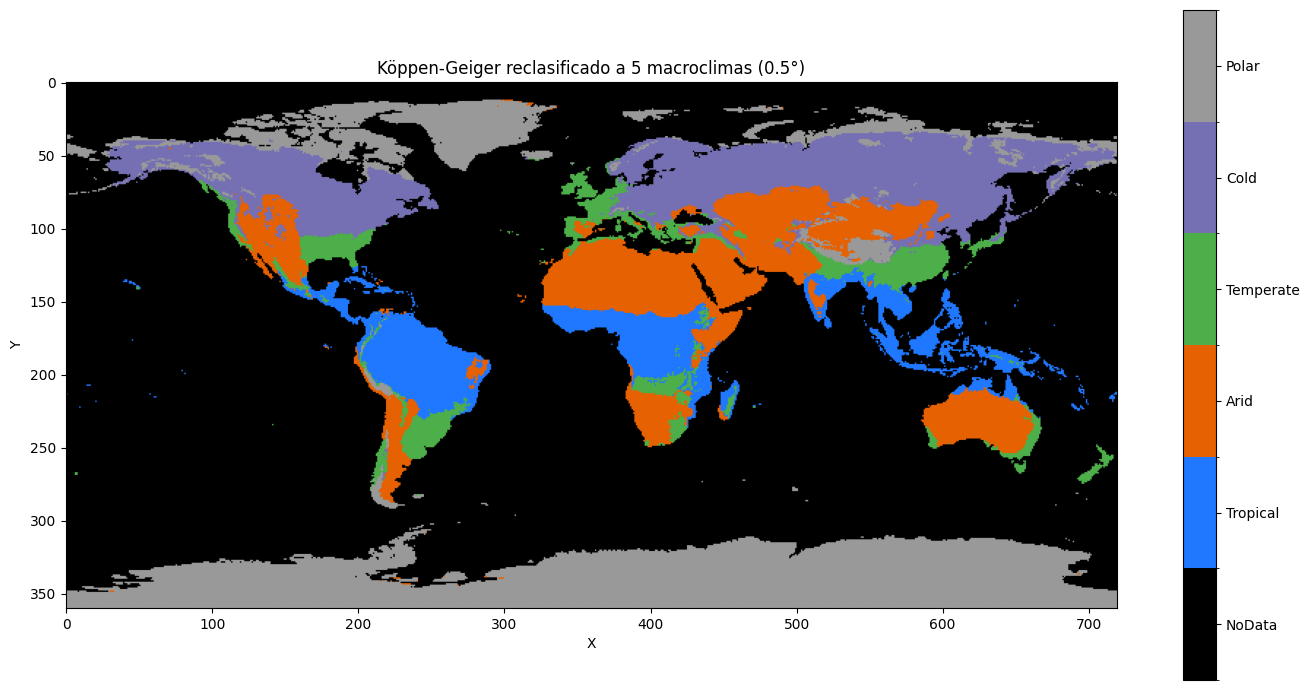

Preview guardada en: /home/dani/github/profecia/data/masks/climate/Beck_KG_V1_present_0p5_5climates_preview.png

Resumen de clases:
0 (NoData): 167153 píxeles
1 (Tropical): 10850 píxeles
2 (Arid): 18263 píxeles
3 (Temperate): 6944 píxeles
4 (Cold): 20579 píxeles
5 (Polar): 35411 píxeles


In [3]:
# Reclasificación
with rasterio.open(input_tif) as src:
    data = src.read(1)
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    nodata_in = src.nodata

    out = np.zeros_like(data, dtype=np.uint8)

    for old_value, new_value in macro_map.items():
        out[data == old_value] = new_value

    if nodata_in is not None:
        out[data == nodata_in] = 0

    profile.update(
        dtype=rasterio.uint8,
        count=1,
        nodata=0,
        compress="lzw"
    )

    with rasterio.open(output_macro_tif, "w", **profile) as dst:
        dst.write(out, 1)

print(f"Raster macroclimático creado: {output_macro_tif}")


# Máscaras binarias
for code, name in macro_names.items():
    mask = (out == code).astype(np.uint8)

    mask_path = output_dir / f"mask_{name}_0p5.tif"
    mask_profile = profile.copy()
    mask_profile.update(dtype=rasterio.uint8, nodata=0, compress="lzw")

    with rasterio.open(mask_path, "w", **mask_profile) as dst:
        dst.write(mask, 1)

    print(f"Máscara creada: {mask_path}")


# Figura de control
cmap = ListedColormap([
    "#000000",  # 0 NoData
    "#1f78ff",  # 1 Tropical
    "#e66101",  # 2 Arid
    "#4daf4a",  # 3 Temperate
    "#7570b3",  # 4 Cold
    "#999999"   # 5 Polar
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

plt.figure(figsize=(14, 7))
img = plt.imshow(out, cmap=cmap, norm=norm)
cbar = plt.colorbar(img, ticks=[0, 1, 2, 3, 4, 5])
cbar.ax.set_yticklabels([macro_labels[i] for i in [0, 1, 2, 3, 4, 5]])
plt.title("Köppen-Geiger reclasificado a 5 macroclimas (0.5°)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()

preview_path = output_dir / "Beck_KG_V1_present_0p5_5climates_preview.png"
plt.savefig(preview_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Preview guardada en: {preview_path}")


# Resumen de clases
unique, counts = np.unique(out, return_counts=True)
print("\nResumen de clases:")
for u, c in zip(unique, counts):
    print(f"{u} ({macro_labels.get(int(u), 'Unknown')}): {c} píxeles")

## Land Cover

In [4]:
input_tif = "/home/dani/github/profecia/data/masks/land_cover/GLASS-GLC_7classes_2000.tif"
output_dir = Path("/home/dani/github/profecia/data/masks/land_cover")
output_dir.mkdir(exist_ok=True, parents=True)

# Grid objetivo global 0.5°
dst_crs = "EPSG:4326"
dst_res = 0.5
dst_width = 720
dst_height = 360
dst_transform = from_origin(-180.0, 90.0, dst_res, dst_res)

class_codes = {
    10: "cropland",
    20: "forest",
    30: "grassland",
    40: "shrubland",
    70: "tundra",
    90: "barren",
    100: "snow_ice",
}

dominant_out = output_dir / "GLASS-GLC_7classes_2000_0p5_dominant.tif"

In [6]:
# Raster categórico dominante a 0.5°
with rasterio.open(input_tif) as src:
    src_data = src.read(1)

    # salida categórica: mantener códigos originales
    dst_dominant = np.zeros((dst_height, dst_width), dtype=np.uint8)

    reproject(
        source=src_data,
        destination=dst_dominant,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        src_nodata=0,
        dst_nodata=0,
        resampling=Resampling.mode
    )

    profile_dom = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": rasterio.uint8,
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": 0,
        "compress": "lzw"
    }

    with rasterio.open(dominant_out, "w", **profile_dom) as dst:
        dst.write(dst_dominant, 1)

print(f"Guardado: {dominant_out}")


# TIFF por clase con fracción ocupada a 0.5°
with rasterio.open(input_tif) as src:
    src_data = src.read(1)

    profile_frac = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": rasterio.float32,
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": -9999.0,
        "compress": "lzw"
    }

    for code, name in class_codes.items():
        binary = (src_data == code).astype(np.float32)
        dst_fraction = np.full((dst_height, dst_width), -9999.0, dtype=np.float32)

        reproject(
            source=binary,
            destination=dst_fraction,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            src_nodata=0.0,
            dst_nodata=-9999.0,
            resampling=Resampling.average
        )

        # por seguridad, limitar a [0, 1]
        valid = dst_fraction != -9999.0
        dst_fraction[valid] = np.clip(dst_fraction[valid], 0.0, 1.0)

        out_path = output_dir / f"lc_{name}_0p5_fraction.tif"
        with rasterio.open(out_path, "w", **profile_frac) as dst:
            dst.write(dst_fraction, 1)

        print(f"Guardado: {out_path}")


# máscaras binarias 0/1 a partir de fracciones
# =========================================================
threshold = 0.5  # mayoría de la celda

for code, name in class_codes.items():
    frac_path = output_dir / f"lc_{name}_0p5_fraction.tif"
    mask_path = output_dir / f"mask_{name}_0p5_binary.tif"

    with rasterio.open(frac_path) as src:
        frac = src.read(1)
        profile_mask = src.profile.copy()
        profile_mask.update(dtype=rasterio.uint8, nodata=0)

        mask = np.zeros_like(frac, dtype=np.uint8)
        valid = frac != src.nodata
        mask[valid & (frac >= threshold)] = 1

        with rasterio.open(mask_path, "w", **profile_mask) as dst:
            dst.write(mask, 1)

    print(f"Guardado: {mask_path}")

Guardado: /home/dani/github/profecia/data/masks/land_cover/GLASS-GLC_7classes_2000_0p5_dominant.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_cropland_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_forest_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_grassland_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_shrubland_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_tundra_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_barren_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/lc_snow_ice_0p5_fraction.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/mask_cropland_0p5_binary.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/mask_forest_0p5_binary.tif
Guardado: /home/dani/github/profecia/data/masks/land_cover/mask_grassland_0p5_binary.tif
Guardado: /home/dani/gith

In [9]:
with rasterio.open("/home/dani/github/profecia/data/masks/land_cover/GLASS-GLC_7classes_2000_0p5_dominant.tif") as src:
    print(src.shape)       # debería ser (360, 720)
    print(src.bounds)      # debería ser (-180, -90, 180, 90)
    print(src.transform)
    print(src.crs)         # EPSG:4326

(360, 720)
BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
| 0.50, 0.00,-180.00|
| 0.00,-0.50, 90.00|
| 0.00, 0.00, 1.00|
EPSG:4326


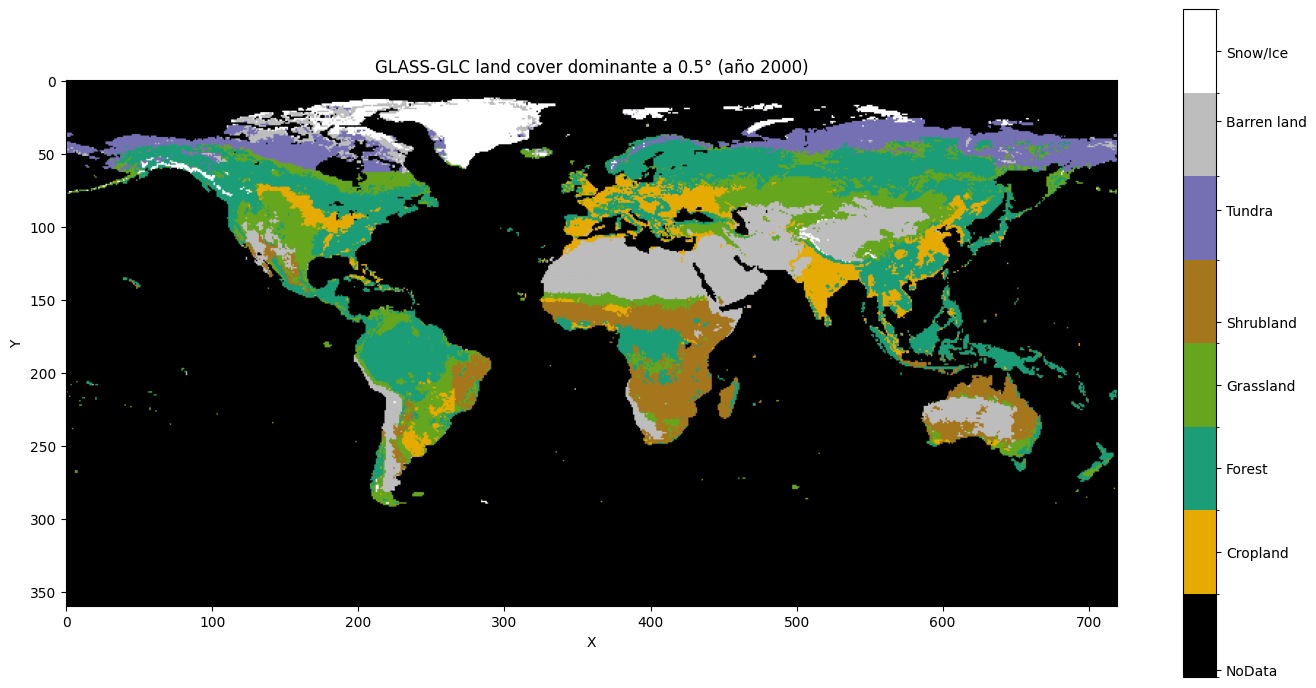

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

out = dst_dominant

lc_labels = {
    0: "NoData",
    10: "Cropland",
    20: "Forest",
    30: "Grassland",
    40: "Shrubland",
    70: "Tundra",
    90: "Barren land",
    100: "Snow/Ice"
}

cmap = ListedColormap([
    "#000000",  # 0 NoData
    "#e6ab02",  # 10 Cropland
    "#1b9e77",  # 20 Forest
    "#66a61e",  # 30 Grassland
    "#a6761d",  # 40 Shrubland
    "#7570b3",  # 70 Tundra
    "#bdbdbd",  # 90 Barren land
    "#ffffff"   # 100 Snow/Ice
])

# Ojo: como los valores no son consecutivos, BoundaryNorm hay que definirlo con sus cortes reales
bounds = [-0.5, 5, 15, 25, 35, 55, 80, 95, 105]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(14, 7))
img = plt.imshow(out, cmap=cmap, norm=norm)
cbar = plt.colorbar(img, ticks=[0, 10, 20, 30, 40, 70, 90, 100])
cbar.ax.set_yticklabels([lc_labels[i] for i in [0, 10, 20, 30, 40, 70, 90, 100]])

plt.title("GLASS-GLC land cover dominante a 0.5° (año 2000)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()

preview_path = output_dir / "GLASS-GLC_7classes_2000_0p5_dominant_preview.png"
plt.savefig(preview_path, dpi=200, bbox_inches="tight")
plt.show()